# GUS01D: Pre-1999 Voivodeship Overlay Analysis

This notebook overlays current gminas onto pre-1999 voivodeship boundaries (49 voivodeships, 1975-1998).

**Workflow:**
1. Load the GeoTERYT database (v3.0)
2. Load pre-1999 voivodeship boundaries from `voivodeships_1975_49_clean_EPSG2180.geojson`
3. Overlay gminas onto old voivodeships using area-based assignment
4. Update database records with `old_woj` and `old_woj_id` attributes
5. Validate and export results
6. Save complete database with pickle for future use

**Required**: Run `02Alt_borders.ipynb` first to generate the voivodeship GeoJSON file with names

**New v3.0 Features Used:**
- `update_records=True` in overlay to add old_woj/old_woj_id to TERYTRecord
- `save_complete()` to persist database with geometries
- `TERYTRecord.display()` for nice output

In [1]:
# =============================================================================
# STEP 1: Imports and Path Setup
# =============================================================================
import os
import sys
from pathlib import Path
import importlib
import gc

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import unary_union

# Find the repository root
def find_repo_root(start=Path.cwd()):
    for p in [start] + list(start.parents):
        if (p / 'Code').exists() or (p / '.git').exists():
            return p
    return start

repo_root = find_repo_root()
tools_path = repo_root / 'Code' / 'tools'
if str(tools_path) not in sys.path:
    sys.path.insert(0, str(tools_path))

# Reload geoTERYT_db to get latest version
import geoTERYT_db as gtdb
importlib.reload(gtdb)

# Data paths
data_root = repo_root.parent.parent / 'Data'
geo_root = data_root / 'Geospatial'
gus_root = data_root / 'GUS'

print(f"Repository root: {repo_root}")
print(f"Data root: {data_root}")
print(f"Geospatial root: {geo_root}")

Repository root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/local_repo/LRDWI-Paper
Data root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data
Geospatial root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial


## Step 2: Load GeoTERYT Database

In [2]:
# =============================================================================
# STEP 2: Load Complete GeoTERYT Database from GUS01C
# =============================================================================
# Use the reloaded module
LEVEL_GMINA = gtdb.LEVEL_GMINA
LEVEL_VOIVODESHIP = gtdb.LEVEL_VOIVODESHIP

# Load the complete database (built and saved in GUS01C)
complete_db_path = geo_root / 'geoteryt_complete.pkl'
db = gtdb.load_complete_database(complete_db_path)

db.print_summary()

Loading complete database from /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_complete.pkl...
  Database version: 3.1
  ✓ Restored geometry data for years: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2015, 2016, 2017, 2018, 2021, 2022, 2023]
  ✓ Loaded 4560 records
  ✓ Year range: 1999 - 2024
  ✓ Records with geometry: 0
GeoTERYT Database Summary (v3.0)
Total records:           4,560
Year range:              1999 - 2024
------------------------------------------------------------
Administrative levels:
  Voivodeships (2):      16
  Powiats (5):           382
  Gminas (6):            4162
------------------------------------------------------------
Change tracking:
  Records with changes:      772
  Records with level changes: 0
  Records with kind changes:  0
------------------------------------------------------------
Geometry:
  Records with geometry: 0
  Geometry years:        [2005, 2006,

In [3]:
# =============================================================================
# STEP 2.5: Assign Geometries for Year 1999
# =============================================================================
# Run the geometry assignment pipeline for year 1999
# This is the same pipeline developed in GUS01D_geoTERYT_geometries.ipynb

target_year = 1999
print(f"Assigning geometries for year {target_year}...")
print(f"Available geometry years: {sorted(db._geometries.keys())}")

# Step 1: assign_geometries - direct match (won't work for 1999 as no geometry file)
result = db.assign_geometries(year=target_year, level=LEVEL_GMINA, verbose=True)

# Step 2: assign_missing_geometries - find from other years for unchanged units
result = db.assign_missing_geometries(year=target_year, level=LEVEL_GMINA, verbose=True)

# Step 3: impute_geometries_past_tid - use historical codes for units with changes
result = db.impute_geometries_past_tid(year=target_year, level=LEVEL_GMINA, verbose=True)

# Step 4: impute_from_best_candidates - apply remaining best candidates
result = db.impute_from_best_candidates(verbose=True)

# Check final status
snapshot = db.get_snapshot(target_year)
gminas = [r for r in snapshot if r.level == LEVEL_GMINA and r.rodz not in ['4', '5', '8', '9']]
with_geom = sum(1 for r in gminas if r.has_geometry)
print(f"\nFinal status: {with_geom}/{len(gminas)} gminas with geometry ({100*with_geom/len(gminas):.1f}%)")

gc.collect()

Assigning geometries for year 1999...
Available geometry years: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2015, 2016, 2017, 2018, 2021, 2022, 2023]
  No geometry data available for year 1999
Finding missing geometries for year 1999...
  Units without geometry: 3650
  Found 15 candidates for 1402035, using year 2005
  Found 15 candidates for 1802015, using year 2005
  Found 15 candidates for 3026023, using year 2005
  Found 15 candidates for 1215063, using year 2005
  Found 15 candidates for 1411052, using year 2005
  Found 15 candidates for 3011045, using year 2005
  Found 15 candidates for 0401052, using year 2005
  Found 15 candidates for 2412015, using year 2005
  Found 15 candidates for 1801084, using year 2005
  Found 15 candidates for 0607062, using year 2005
  Found 15 candidates for 1406074, using year 2005
  Found 15 candidates for 1017082, using year 2005
  Found 15 candidates for 0208133, using year 2005
  Found 15 candidates for 1601062, using year 2005
  Found 15 ca

3032

2478


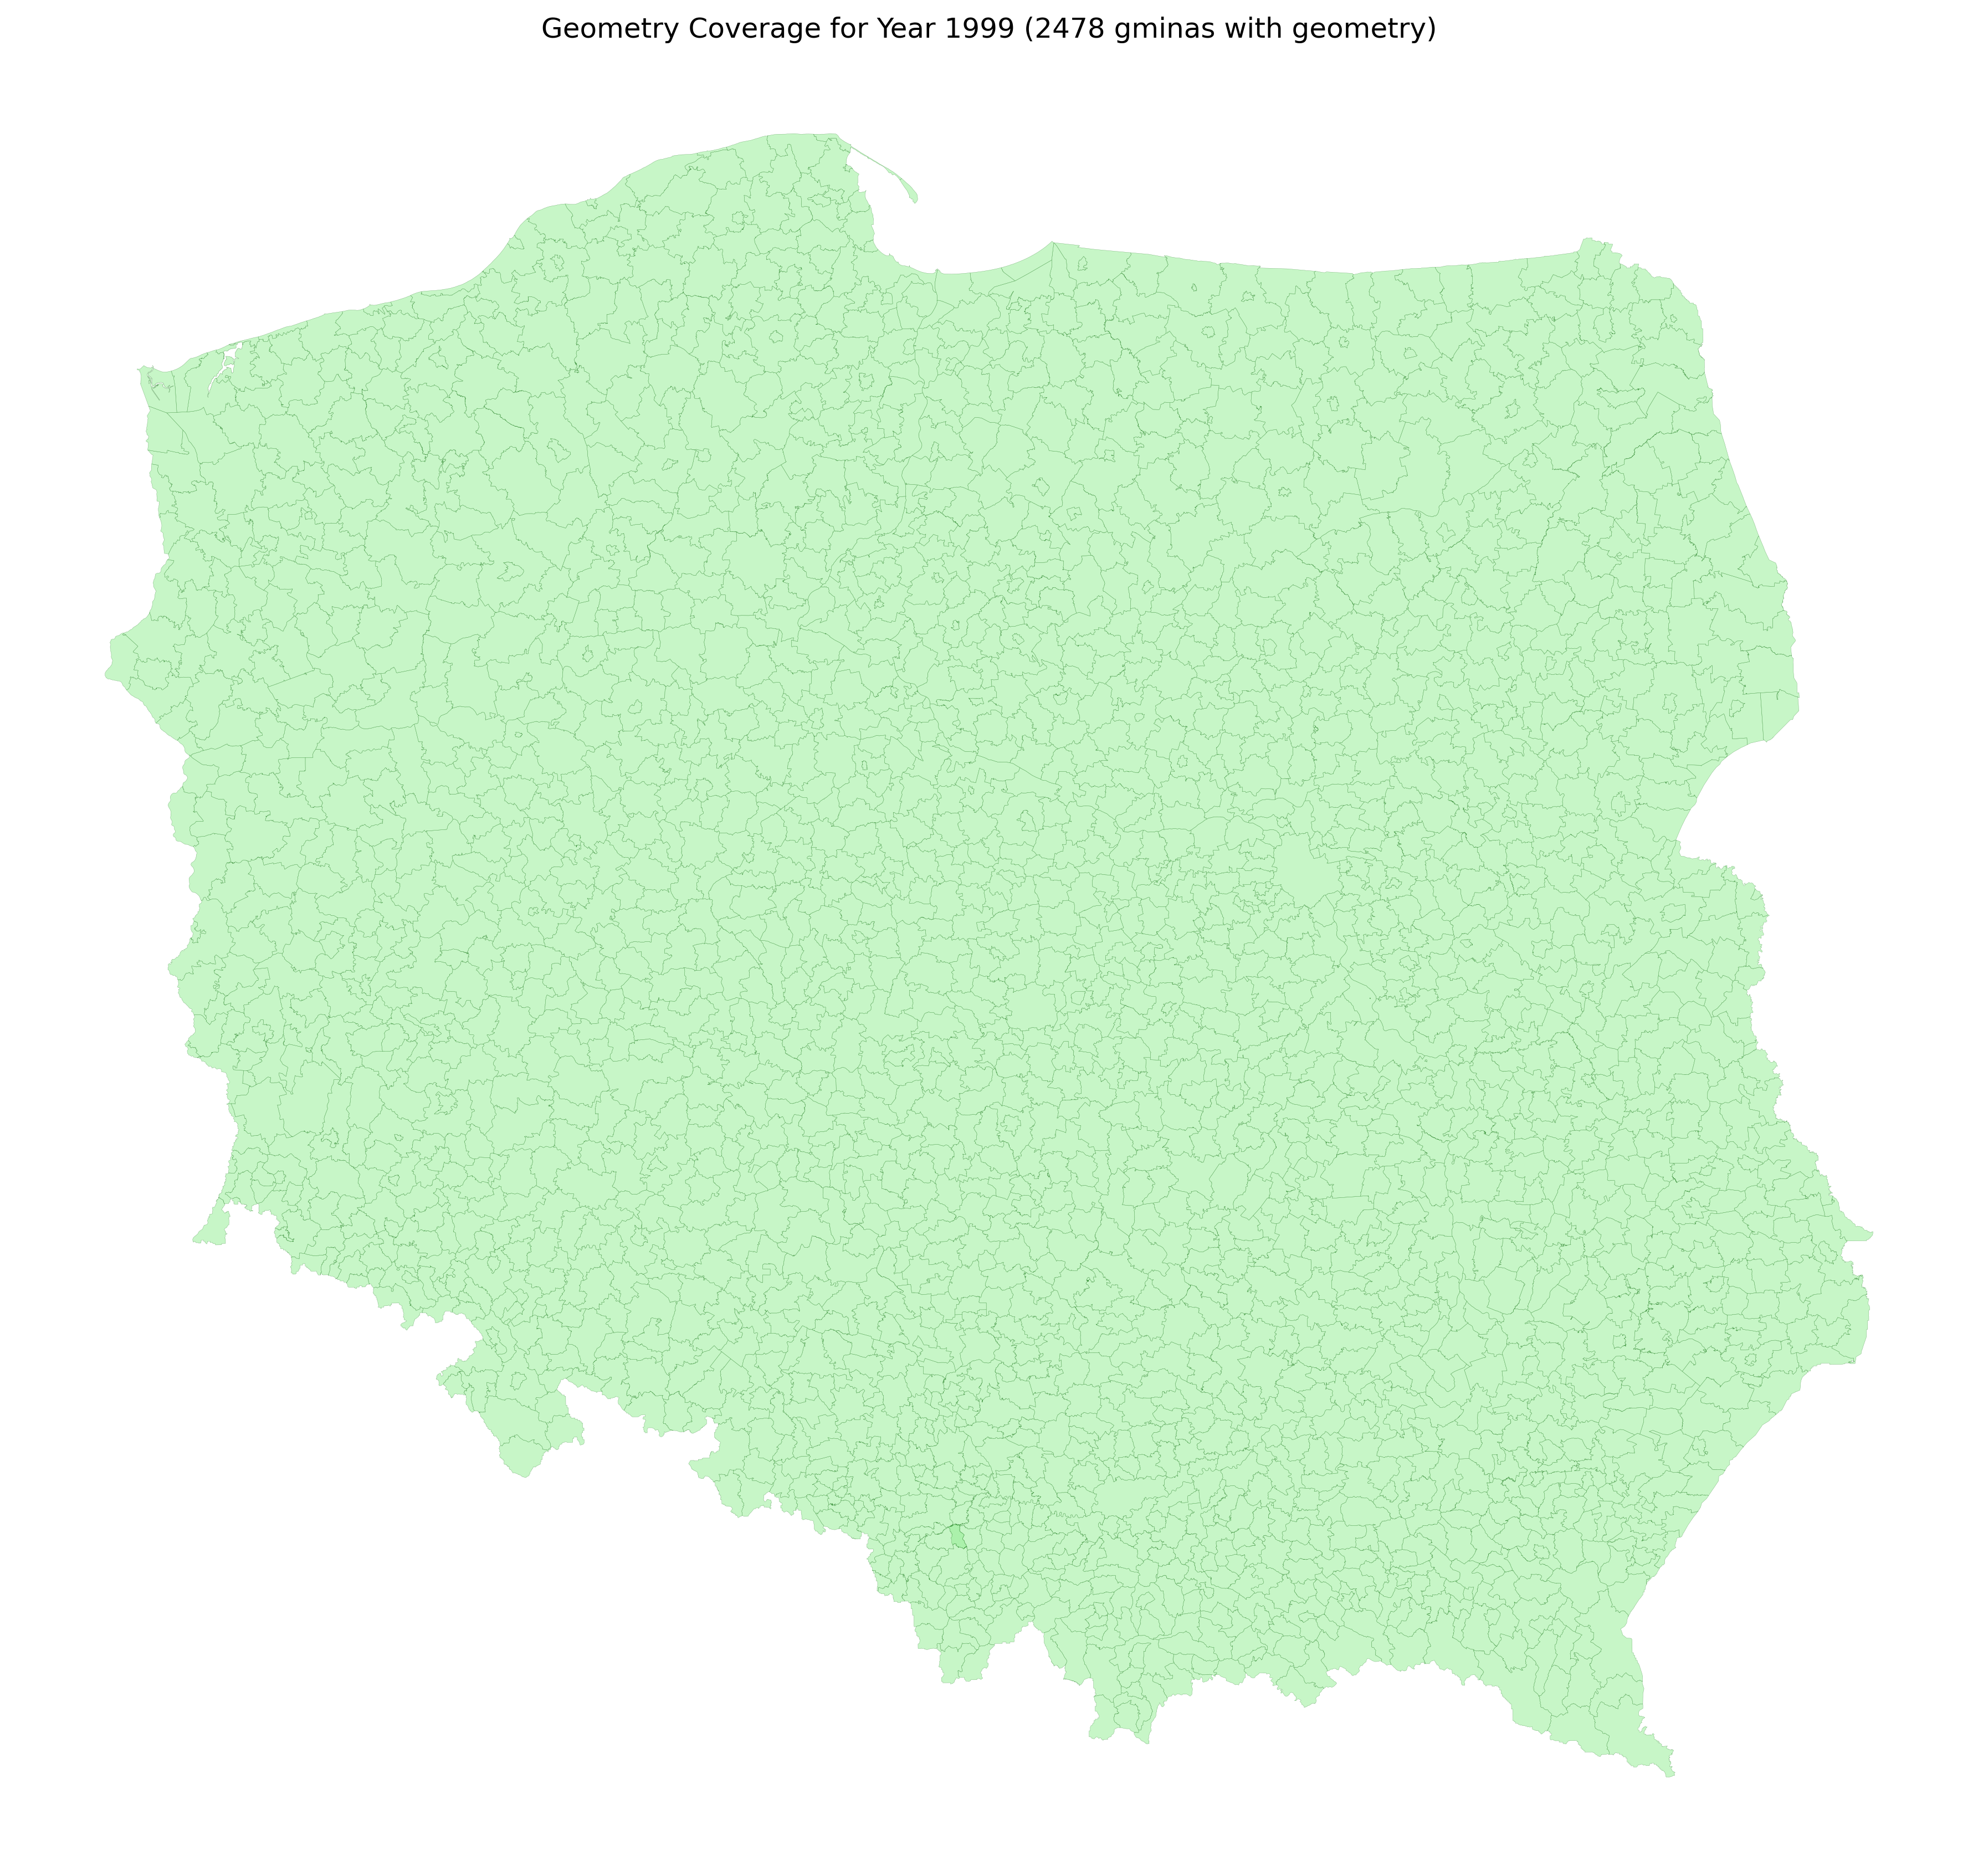

65

In [4]:
# Check the geometries map
# Visualize coverage for a specific year

gdf = db.to_geodataframe(year=target_year, level=6, exclude_subdivisions=True, only_with_geometry=True)
print(len(gdf))
poland = db.get_poland_boundary()

fig, ax = plt.subplots(1, 1, figsize=(12, 12), dpi = 300)

# Plot Poland boundary first (as background)
if poland is not None:
    gpd.GeoSeries([poland]).plot(ax=ax, color='lightcoral', alpha=0.5, label='Missing')

# Plot gminas with geometry
gdf.plot(ax=ax, facecolor='lightgreen', edgecolor='darkgreen', linewidth=0.1, alpha=0.5)

ax.set_title(f'Geometry Coverage for Year {target_year} ({len(gdf)} gminas with geometry)')
ax.set_axis_off()
plt.tight_layout()
plt.show()
gc.collect()

## Step 3: Load Pre-1999 Voivodeship Boundaries

In [5]:
# =============================================================================
# STEP 3: Load Pre-1999 Voivodeship Boundaries
# =============================================================================
# pre1999_path = geo_root / 'voivodeships_1975_final.geojson'
pre1999_path = geo_root / 'voivodeships_1975_49_clean_EPSG2180.geojson'

if not pre1999_path.exists():
    raise FileNotFoundError(f"Pre-1999 boundaries not found: {pre1999_path}\nRun 02_borders.ipynb first!")

pre1999_gdf = gpd.read_file(pre1999_path)
pre1999_gdf = pre1999_gdf.to_crs('EPSG:2180')  # Ensure projected CRS

print(f"Loaded {len(pre1999_gdf)} pre-1999 voivodeships")
print(f"Expected: 49 voivodeships")
print(f"\nVoivodeship areas (sample):")
for idx, row in pre1999_gdf.head(10).iterrows():
    area_km2 = row.geometry.area / 1e6
    print(f"  {row['name']}: {area_km2:,.0f} km²")

# Sanity check: total area should be ~312,685 km²
total_area = pre1999_gdf.geometry.area.sum() / 1e6
print(f"\nTotal area: {total_area:,.0f} km² (Poland ≈ 312,685 km²)")

Loaded 49 pre-1999 voivodeships
Expected: 49 voivodeships

Voivodeship areas (sample):
  bialskopodlaskie: 5,348 km²
  białostockie: 10,069 km²
  bielskie: 3,700 km²
  bydgoskie: 10,344 km²
  chełmskie: 3,879 km²
  ciechanowskie: 6,356 km²
  częstochowskie: 6,176 km²
  elbląskie: 6,110 km²
  gdańskie: 7,388 km²
  gorzowskie: 8,483 km²

Total area: 312,648 km² (Poland ≈ 312,685 km²)


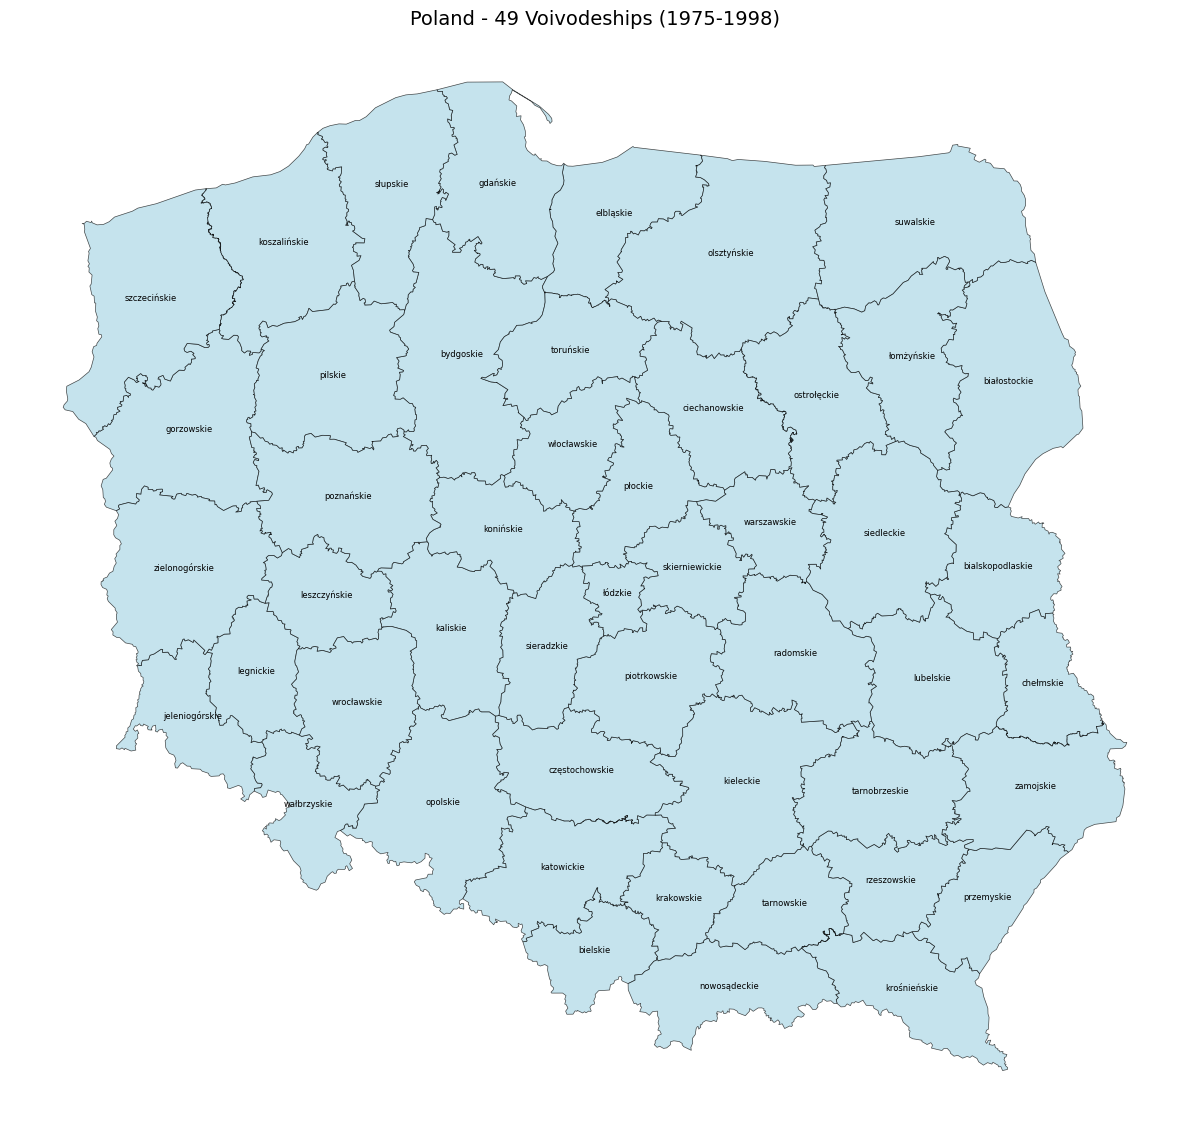

In [6]:
# Visualize pre-1999 voivodeships
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
pre1999_gdf.plot(ax=ax, edgecolor='black', linewidth=0.5, facecolor='lightblue', alpha=0.7)

for idx, row in pre1999_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['name'], xy=(centroid.x, centroid.y), ha='center', fontsize=6)

ax.set_title('Poland - 49 Voivodeships (1975-1998)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

## Step 4: Overlay Gminas onto Pre-1999 Voivodeships

In [7]:
# =============================================================================
# STEP 4: Overlay Gminas onto Pre-1999 Voivodeships
# =============================================================================
# Use 'area' method for most accurate assignment (assigns to voivodeship with max overlap)
# Set update_records=True to add old_woj and old_woj_id attributes to database records
year = 1999  # Use 1999 gminas for pre-1999 voivodeship assignment

db.set_old_voivodship_gdf(pre1999_gdf)  # Set the pre-1999 voivodeship GeoDataFrame in the database

result_gdf = db.assign_gminas_to_pre1999_voivodeships(
    year=year,
    pre1999_boundaries_gdf=pre1999_gdf,
    voivodeship_name_col='name',
    voivodeship_id_col='voiv_id',  # Now available in the GeoJSON
    method='area',  # Use area overlap for accurate assignment
    update_records=True  # Update database records with old_woj, old_woj_id
)

print(f"Overlay complete for year {year}!")
print(f"\nGminas per pre-1999 voivodeship (top 15):")
print(result_gdf['pre1999_voivodeship'].value_counts().head(15))

# Check for unassigned gminas
unassigned_count = result_gdf['pre1999_voivodeship'].isna().sum()
print(f"\nUnassigned gminas: {unassigned_count}")

Assigning 2478 gminas to pre-1999 voivodeships...
  ✓ Assigned 2478 gminas to voivodeships
  ✓ Updated 2478 database records with old_woj/old_woj_id
Overlay complete for year 1999!

Gminas per pre-1999 voivodeship (top 15):
pre1999_voivodeship
katowickie        98
kieleckie         80
siedleckie        75
lubelskie         69
opolskie          65
gdańskie          63
radomskie         63
poznańskie        62
nowosądeckie      60
bielskie          59
bydgoskie         59
częstochowskie    58
kaliskie          58
olsztyńskie       58
zielonogórskie    57
Name: count, dtype: int64

Unassigned gminas: 0


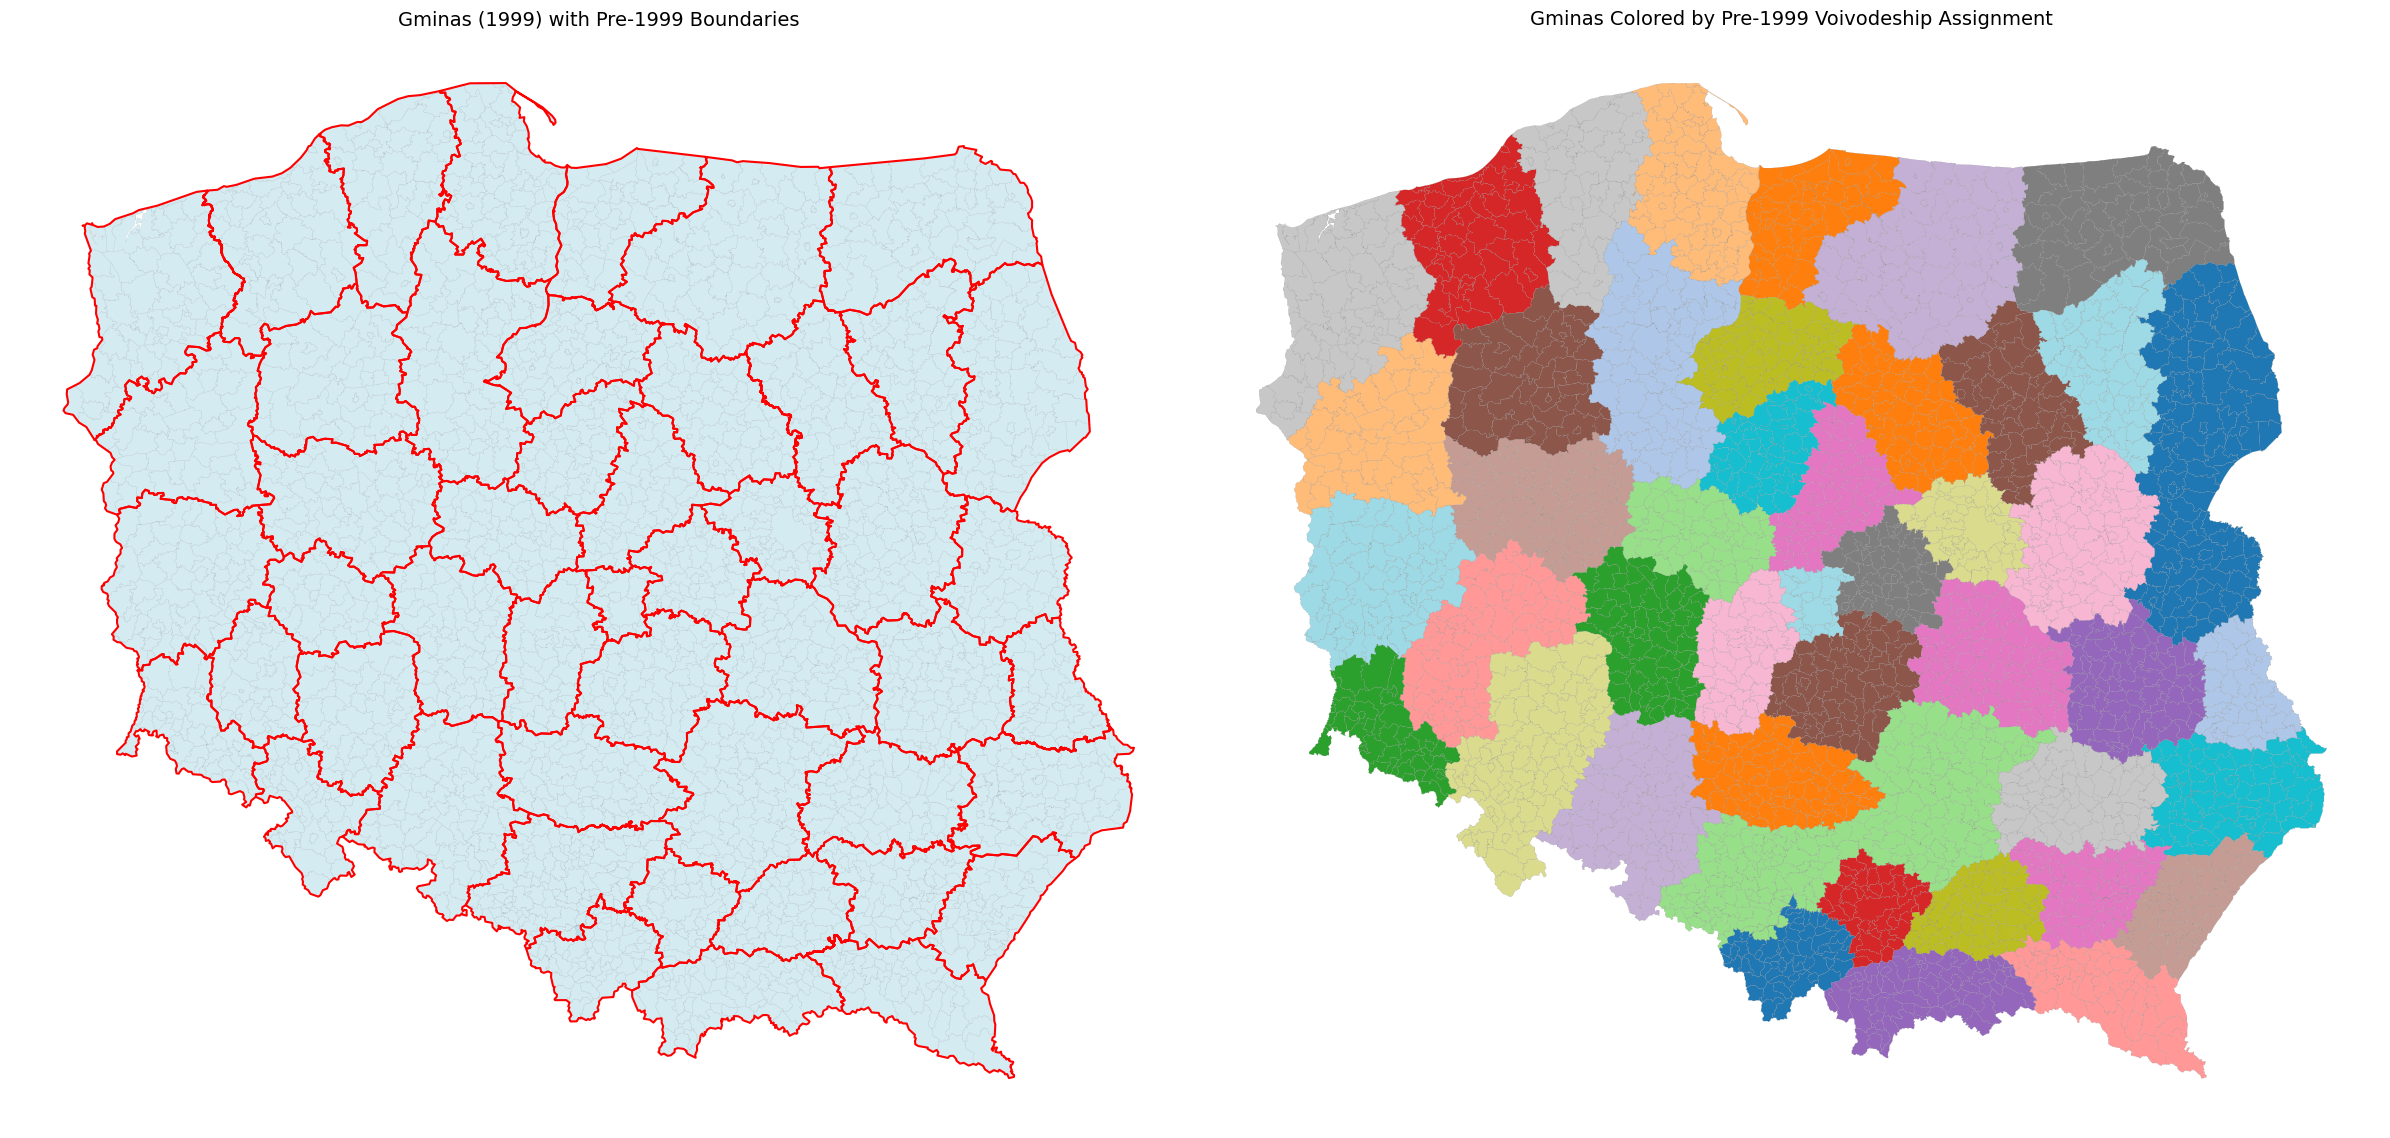

In [8]:
# Visualize overlay results
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# Left: Pre-1999 boundaries overlaid on gminas
ax1 = axes[0]
result_gdf.plot(ax=ax1, edgecolor='gray', linewidth=0.1, facecolor='lightblue', alpha=0.5)
pre1999_gdf.plot(ax=ax1, edgecolor='red', linewidth=1.5, facecolor='none')
ax1.set_title(f'Gminas ({year}) with Pre-1999 Boundaries', fontsize=14)
ax1.axis('off')

# Right: Gminas colored by assigned voivodeship
ax2 = axes[1]
result_gdf.plot(ax=ax2, column='pre1999_voivodeship', edgecolor='gray', linewidth=0.1, cmap='tab20', legend=False)
ax2.set_title('Gminas Colored by Pre-1999 Voivodeship Assignment', fontsize=14)
ax2.axis('off')

plt.tight_layout()
plt.show()

## Step 5: Validate Results

In [9]:
# =============================================================================
# STEP 5: Validate Results
# =============================================================================

# Get current voivodeship names for cross-reference
voiv_records = db.get_divisions_by_level(LEVEL_VOIVODESHIP)
voiv_names = {r.woj: r.name for r in voiv_records}
result_gdf['current_voivodeship'] = result_gdf['woj'].map(voiv_names)

# Cross-tabulation: Current vs Pre-1999 voivodeships
print("Mapping: Current Voivodeships → Pre-1999 Voivodeships")
print("=" * 60)

for current_voiv in sorted(result_gdf['current_voivodeship'].dropna().unique()):
    gminas_in_voiv = result_gdf[result_gdf['current_voivodeship'] == current_voiv]
    old_voivs = gminas_in_voiv['pre1999_voivodeship'].value_counts().head(3)
    print(f"\n{current_voiv} ({len(gminas_in_voiv)} gminas):")
    for old_voiv, count in old_voivs.items():
        pct = 100 * count / len(gminas_in_voiv)
        print(f"  → {old_voiv}: {count} ({pct:.1f}%)")

Mapping: Current Voivodeships → Pre-1999 Voivodeships

DOLNOŚLĄSKIE (169 gminas):
  → wałbrzyskie: 45 (26.6%)
  → jeleniogórskie: 40 (23.7%)
  → wrocławskie: 40 (23.7%)

KUJAWSKO-POMORSKIE (144 gminas):
  → bydgoskie: 54 (37.5%)
  → włocławskie: 46 (31.9%)
  → toruńskie: 44 (30.6%)

LUBELSKIE (213 gminas):
  → lubelskie: 69 (32.4%)
  → zamojskie: 57 (26.8%)
  → bialskopodlaskie: 34 (16.0%)

LUBUSKIE (83 gminas):
  → zielonogórskie: 54 (65.1%)
  → gorzowskie: 27 (32.5%)
  → leszczyńskie: 2 (2.4%)

MAZOWIECKIE (314 gminas):
  → siedleckie: 63 (20.1%)
  → radomskie: 61 (19.4%)
  → warszawskie: 47 (15.0%)

MAŁOPOLSKIE (182 gminas):
  → nowosądeckie: 60 (33.0%)
  → krakowskie: 39 (21.4%)
  → tarnowskie: 38 (20.9%)

OPOLSKIE (71 gminas):
  → opolskie: 65 (91.5%)
  → częstochowskie: 6 (8.5%)

PODKARPACKIE (160 gminas):
  → rzeszowskie: 47 (29.4%)
  → krośnieńskie: 42 (26.2%)
  → przemyskie: 41 (25.6%)

PODLASKIE (118 gminas):
  → białostockie: 55 (46.6%)
  → łomżyńskie: 41 (34.7%)
  → suwalsk

In [10]:
# Sanity check: Look for suspicious assignments
# Białostockie should only contain gminas from Podlaskie (woj=20)

suspicious = result_gdf[
    (result_gdf['pre1999_voivodeship'] == 'bialostockie') & 
    (result_gdf['woj'] != '20')
]

print(f"Sanity Check: białostockie assignments outside Podlaskie")
print(f"Suspicious assignments: {len(suspicious)}")

if len(suspicious) > 0:
    print("\nSuspicious gminas (may be boundary edge cases):")
    print(suspicious[['teryt_id', 'name', 'current_voivodeship']].head(10).to_string())
else:
    print("✓ All białostockie assignments are within Podlaskie - data looks correct!")

Sanity Check: białostockie assignments outside Podlaskie
Suspicious assignments: 0
✓ All białostockie assignments are within Podlaskie - data looks correct!


## Step 6: Export Results

In [11]:
# =============================================================================
# STEP 6: Export Results
# =============================================================================

# Export as GeoJSON (with geometry)
output_geojson = geo_root / f'gminas_{year}_with_pre1999_voiv.geojson'
result_gdf.to_file(output_geojson, driver='GeoJSON')
print(f"✓ Exported GeoJSON: {output_geojson}")

# Export as CSV (without geometry, for easy analysis)
output_csv = geo_root / f'gminas_{year}_pre1999_mapping.csv'
result_df = result_gdf.drop(columns='geometry')
result_df.to_csv(output_csv, index=False)
print(f"✓ Exported CSV: {output_csv}")

# Summary
print(f"\n{'='*60}")
print(f"SUMMARY")
print(f"{'='*60}")
print(f"Total gminas: {len(result_gdf):,}")
print(f"Assigned to pre-1999 voivodeships: {result_gdf['pre1999_voivodeship'].notna().sum():,}")
print(f"Unique pre-1999 voivodeships: {result_gdf['pre1999_voivodeship'].nunique()}")
print(f"{'='*60}")

✓ Exported GeoJSON: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/gminas_1999_with_pre1999_voiv.geojson
✓ Exported CSV: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/gminas_1999_pre1999_mapping.csv

SUMMARY
Total gminas: 2,478
Assigned to pre-1999 voivodeships: 2,478
Unique pre-1999 voivodeships: 49


## Step 7: Verify old_woj Attributes in Database Records

In [12]:
# =============================================================================
# STEP 7: Verify old_woj Attributes in Database Records
# =============================================================================
# Check that database records now have old_woj and old_woj_id attributes

# Sample a few gminas
sample_gminas = db.get_divisions_by_year(year, level=LEVEL_GMINA)[:10]

print("Sample gminas with old_woj assignments:")
print("-" * 70)
for g in sample_gminas:
    print(f"  {g.teryt_id} {g.name:<25} → old_woj: {g.old_woj}, old_woj_id: {g.old_woj_id}")

# Count gminas with old_woj assigned
all_gminas = db.get_divisions_by_year(year, level=LEVEL_GMINA)
with_old_woj = sum(1 for g in all_gminas if g.old_woj is not None)
print(f"\n✓ {with_old_woj}/{len(all_gminas)} gminas have old_woj assigned")

# Show new display() method
print("\n\nUsing TERYTRecord.display() method:")
sample_gminas[0].display()

Sample gminas with old_woj assignments:
----------------------------------------------------------------------
  2806032 Budry                     → old_woj: suwalskie, old_woj_id: 36
  3026023 Dolsk                     → old_woj: poznańskie, old_woj_id: 28
  1215063 Maków Podhalański         → old_woj: bielskie, old_woj_id: 3
  1411052 Młynarze                  → old_woj: ostrołęckie, old_woj_id: 25
  0401052 Bądkowo                   → old_woj: włocławskie, old_woj_id: 45
  0607062 Szastarka                 → old_woj: tarnobrzeskie, old_woj_id: 39
  1017082 Skomlin                   → old_woj: sieradzkie, old_woj_id: 34
  0208133 Stronie Śląskie           → old_woj: wałbrzyskie, old_woj_id: 43
  1601062 Olszanka                  → old_woj: opolskie, old_woj_id: 24
  2610053 Suchedniów                → old_woj: kieleckie, old_woj_id: 14

✓ 2478/2490 gminas have old_woj assigned


Using TERYTRecord.display() method:


,Field,Value
0,teryt_id,2806032
1,name,Budry
2,name_dod,gmina wiejska
3,level,6
4,kind,rural
5,woj,28
6,pow,06
7,gmi,03
8,rodz,2
9,years_valid,"[np.int64(1999), np.int64(2000), np.int64(2001)]"


## Step 8: Save Complete Database with Old Voivodeship Assignments

In [13]:
# =============================================================================
# STEP 8: Save Complete Database with Old Voivodeship Assignments
# =============================================================================
# Save the database with all records updated with old_woj assignments

complete_db_path = geo_root / 'geoteryt_complete_geom_OW.pkl'
db.save_complete(complete_db_path)

print(f"✓ Complete database saved to: {complete_db_path}")
print(f"\nTo load this database elsewhere:")
print("    from geoTERYT_db import load_complete_database")
print(f"    db = load_complete_database('{complete_db_path.name}')")

Saving complete database to /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_complete_geom_OW.pkl...
  ✓ Saved 4560 records
  ✓ File size: 1154.2 MB
  ✓ Path: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_complete_geom_OW.pkl
✓ Complete database saved to: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_complete_geom_OW.pkl

To load this database elsewhere:
    from geoTERYT_db import load_complete_database
    db = load_complete_database('geoteryt_complete_geom_OW.pkl')


In [14]:
records = db._records
i = 0
for key, record in records.items():
    level = record.level
    rodz = record.rodz
    if level == 6 and rodz in ["1", "2", "3"]:
        old_voivodship = record.old_woj
        if old_voivodship is None:
            print(f"Unit: {record.name} with {record.teryt_id} without old_voivodship. It has {len(record.historical_codes)}")
            i += 1
print(f"\nTotal gminas without old_voivodship: {i}")
gc.collect()

Unit: Warszawa-Bemowo with 1431011 without old_voivodship. It has 2
Unit: Warszawa-Białołęka with 1431021 without old_voivodship. It has 2
Unit: Warszawa-Bielany with 1431031 without old_voivodship. It has 2
Unit: Warszawa-Centrum with 1431041 without old_voivodship. It has 1
Unit: Warszawa-Rembertów with 1431121 without old_voivodship. It has 2
Unit: Warszawa-Targówek with 1431131 without old_voivodship. It has 2
Unit: Warszawa-Ursus with 1431141 without old_voivodship. It has 2
Unit: Warszawa-Ursynów with 1431151 without old_voivodship. It has 2
Unit: Warszawa-Wawer with 1431161 without old_voivodship. It has 2
Unit: Warszawa-Wilanów with 1431171 without old_voivodship. It has 2
Unit: Warszawa-Włochy with 1431181 without old_voivodship. It has 2
Unit: Warszawa with 1431001 without old_voivodship. It has 1
Unit: Prusice with 0220023 without old_voivodship. It has 2
Unit: Tyszowce with 0618123 without old_voivodship. It has 2
Unit: Czchów with 1202033 without old_voivodship. It has 2
U

5783

In [15]:
db.update_affilated_gminas_to_pre1999_voivodeships()
i = 0
records = db._records
for key, record in records.items():
    level = record.level
    rodz = record.rodz
    if level == 6 and rodz in ["1", "2", "3"]:
        old_voivodship = record.old_woj
        if old_voivodship is None:
            print(f"Unit: {record.name} with {record.teryt_id} without old_voivodship. It has {len(record.historical_codes)}")
            i += 1
print(f"\nTotal gminas without old_voivodship after update: {i}")

Updated 180 gminas with old_woj_id based on historical codes.
Unit: Warszawa-Bemowo with 1431011 without old_voivodship. It has 2
Unit: Warszawa-Białołęka with 1431021 without old_voivodship. It has 2
Unit: Warszawa-Bielany with 1431031 without old_voivodship. It has 2
Unit: Warszawa-Centrum with 1431041 without old_voivodship. It has 1
Unit: Warszawa-Rembertów with 1431121 without old_voivodship. It has 2
Unit: Warszawa-Targówek with 1431131 without old_voivodship. It has 2
Unit: Warszawa-Ursus with 1431141 without old_voivodship. It has 2
Unit: Warszawa-Ursynów with 1431151 without old_voivodship. It has 2
Unit: Warszawa-Wawer with 1431161 without old_voivodship. It has 2
Unit: Warszawa-Wilanów with 1431171 without old_voivodship. It has 2
Unit: Warszawa-Włochy with 1431181 without old_voivodship. It has 2
Unit: Warszawa with 1431001 without old_voivodship. It has 1
Unit: Jaśliska with 1807102 without old_voivodship. It has 1

Total gminas without old_voivodship after update: 13


In [16]:
# =============================================================================
# STEP 8: Save Complete Database with Old Voivodeship Assignments
# =============================================================================
# Save the database with all records updated with old_woj assignments

complete_db_path = geo_root / 'geoteryt_complete_geom_OW.pkl'
db.save_complete(complete_db_path)

print(f"✓ Complete database saved to: {complete_db_path}")
print(f"\nTo load this database elsewhere:")
print("    from geoTERYT_db import load_complete_database")
print(f"    db = load_complete_database('{complete_db_path.name}')")

Saving complete database to /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_complete_geom_OW.pkl...
  ✓ Saved 4560 records
  ✓ File size: 1154.2 MB
  ✓ Path: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_complete_geom_OW.pkl
✓ Complete database saved to: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_complete_geom_OW.pkl

To load this database elsewhere:
    from geoTERYT_db import load_complete_database
    db = load_complete_database('geoteryt_complete_geom_OW.pkl')
